**Generate Dataset**
Automation codes to run localhost and download data from stirsimul

**Imports and Model Setup**

In [127]:
import torch
print("PyTorch version:", torch.__version__)  # Should show CUDA version
print("CUDA version in PyTorch:", torch.version.cuda)  # Should match installed CUDA (e.g., 12.1)
print("CUDA available:", torch.cuda.is_available())  # Should return True
print("Number of GPUs:", torch.cuda.device_count())  # Should be > 0
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

PyTorch version: 2.5.1+cu121
CUDA version in PyTorch: 12.1
CUDA available: True
Number of GPUs: 1
GPU Name: NVIDIA GeForce RTX 3060


In [128]:
import numpy as np
import matplotlib.pyplot as plt
import random
import tifffile
from PIL import Image
import glob
from pathlib import Path
import timm.layers
import tqdm
from patchify import patchify 

torch.cuda.is_available()

True

In [129]:
from mobile_sam import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

model_type = "vit_t"
sam_checkpoint = "weights/mobile_sam.pt"
device = "cpu" # set device to cpu temporarily for dataset transforms

mobile_sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
mobile_sam.to(device=device)

predictor = SamPredictor(mobile_sam)
mask_generator = SamAutomaticMaskGenerator(mobile_sam)

c:\Users\user\Documents\Viscnet\MobileSAM_Vortex\mobile_sam\build_sam.py:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


**Generate Dataset**

In [130]:
# Load and stack color images into TIFF format
rawSet = [np.array(Image.open(file)) for file in sorted(glob.glob("captures/raw/raw_*.png"))]
maskedSet = [np.array(Image.open(file)) for file in sorted(glob.glob("captures/masked/masked_*.png"))]

# Save as multi-page TIFF stacks with RGB for color images
tifffile.imwrite("captures/raw_stack.tif", np.array(rawSet), photometric='rgb')
tifffile.imwrite("captures/masked_stack.tif", np.array(maskedSet), photometric='rgb')

In [131]:
# SHAPE : (N, H, W, C)
large_rawSet_temp = tifffile.imread("captures/raw_stack.tif")
large_maskedSet_temp = tifffile.imread("captures/masked_stack.tif")

print(large_rawSet_temp.shape) 
print(large_maskedSet_temp.shape)

(960, 1024, 1024, 4)
(960, 1024, 1024, 4)


In [132]:
large_maskedSet = large_maskedSet_temp[..., 0]  # Take only the RGB channel
large_maskedSet = large_maskedSet.astype(np.uint8) 

large_rawSet = large_rawSet_temp[:, :, :, :3]
large_maskedSet = large_maskedSet[:, :, :]
print(large_rawSet.shape) 
print(large_maskedSet.shape)

(960, 1024, 1024, 3)
(960, 1024, 1024)


In [133]:
#Desired patch size for smaller images and step size.
patch_size = 256
step = 256

all_raw_patches = []
for raw in range(large_rawSet.shape[0]):
    large_raw = large_rawSet[raw]
    
    # Patchify with (patch_size, patch_size, 4) to include RGBA channels
    patches_raw = patchify(large_raw, (patch_size, patch_size, 3), step=step)

    # Iterate through the patches and append to all_img_patches
    for i in range(patches_raw.shape[0]):
        for j in range(patches_raw.shape[1]):
            single_patch_raw = patches_raw[i, j, 0, :, :, :]  # Extract each patch with all channels
            all_raw_patches.append(single_patch_raw)

# Convert list of patches to numpy array
rawSet = np.array(all_raw_patches)

# Process masks, assuming they are single-channel (binary)
all_masked_patches = []
for mask in range(large_maskedSet.shape[0]):
    large_masked = large_maskedSet[mask]

    # If the mask has an extra channel dimension, reduce to single channel
    if large_masked.ndim == 3 and large_masked.shape[-1] == 4:
        large_masked = large_masked[:, :, 0]  # Take only one channel

    # Patchify for 2D patches on single-channel masks
    patches_masked = patchify(large_masked, (patch_size, patch_size), step=step)

    for i in range(patches_masked.shape[0]):
        for j in range(patches_masked.shape[1]):
            single_patch_masked = patches_masked[i, j, :, :]  # Extract as 2D array
            single_patch_masked = (single_patch_masked / 255).astype(np.uint8)  # Normalize to binary if needed
            all_masked_patches.append(single_patch_masked)

# Convert list of patches to numpy array
maskedSet = np.array(all_masked_patches)

# Create a list to store the indices of non-empty masks
valid_indices = [i for i, mask in enumerate(maskedSet) if mask.max() != 0]

# Filter the image and mask arrays to keep only the non-empty pairs
filtered_raw = rawSet[valid_indices]
filtered_masked = maskedSet[valid_indices]
print("Raw shape:", filtered_raw.shape)  # e.g., (num_frames, height, width, num_channels)
print("Masked shape:", filtered_masked.shape)


Raw shape: (6506, 256, 256, 3)
Masked shape: (6506, 256, 256)


In [134]:
import torch

#Get bounding boxes from mask.
def get_bounding_box(ground_truth_map):
  # get bounding box from mask
  y_indices, x_indices = np.where(ground_truth_map > 0)
  x_min, x_max = np.min(x_indices), np.max(x_indices)
  y_min, y_max = np.min(y_indices), np.max(y_indices)
  # add perturbation to bounding box coordinates
  H, W = ground_truth_map.shape
  x_min = max(0, x_min - np.random.randint(0, 20))
  x_max = min(W, x_max + np.random.randint(0, 20))
  y_min = max(0, y_min - np.random.randint(0, 20))
  y_max = min(H, y_max + np.random.randint(0, 20))
  bbox = np.array([x_min, y_min, x_max, y_max])

  return bbox

# Add bounding boxes to the dataset
filtered_boxes = []
for mask in filtered_masked:
  filtered_boxes.append(get_bounding_box(mask))


In [135]:
'''
import cv2
import numpy as np
import torch

#opening(erosion and dilation)

def augment_mask(mask_tensor, kernel_size=3, iterations=1, operation="open"):
    """
    Applies a morphological operation to a mask tensor.
    
    Parameters:
      mask_tensor (torch.Tensor): A tensor of shape [1, H, W] with values in [0, 1].
      kernel_size (int): Size of the square kernel.
      iterations (int): Number of iterations.
      operation (str): 'erode', 'dilate', 'open', or 'close'.
    
    Returns:
      torch.Tensor: The augmented mask tensor of shape [1, H, W] with values in [0, 1].
    """
    # Convert the mask tensor to a NumPy array.
    mask_np = mask_tensor.squeeze(0).cpu().numpy()  # Shape: [H, W]
    
    # Scale mask to 0-255 and convert to uint8 for OpenCV.
    mask_np = (mask_np * 255).astype(np.uint8)
    
    # Define a square kernel.
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    
    # Apply the selected morphological operation.
    if operation == "erode":
        augmented = cv2.erode(mask_np, kernel, iterations=iterations)
    elif operation == "dilate":
        augmented = cv2.dilate(mask_np, kernel, iterations=iterations)
    elif operation == "open":
        augmented = cv2.dilate(cv2.erode(mask_np, kernel, iterations=iterations), kernel, iterations=iterations)
    elif operation == "close":
        augmented = cv2.erode(cv2.dilate(mask_np, kernel, iterations=iterations), kernel, iterations=iterations)
    else:
        augmented = mask_np
    
    # Convert back to a torch tensor with float values in [0, 1] and add the channel dimension.
    augmented_tensor = torch.from_numpy(augmented.astype(np.float32) / 255.0).unsqueeze(0)
    return augmented_tensor
'''

'\nimport cv2\nimport numpy as np\nimport torch\n\n#opening(erosion and dilation)\n\ndef augment_mask(mask_tensor, kernel_size=3, iterations=1, operation="open"):\n    """\n    Applies a morphological operation to a mask tensor.\n    \n    Parameters:\n      mask_tensor (torch.Tensor): A tensor of shape [1, H, W] with values in [0, 1].\n      kernel_size (int): Size of the square kernel.\n      iterations (int): Number of iterations.\n      operation (str): \'erode\', \'dilate\', \'open\', or \'close\'.\n    \n    Returns:\n      torch.Tensor: The augmented mask tensor of shape [1, H, W] with values in [0, 1].\n    """\n    # Convert the mask tensor to a NumPy array.\n    mask_np = mask_tensor.squeeze(0).cpu().numpy()  # Shape: [H, W]\n    \n    # Scale mask to 0-255 and convert to uint8 for OpenCV.\n    mask_np = (mask_np * 255).astype(np.uint8)\n    \n    # Define a square kernel.\n    kernel = np.ones((kernel_size, kernel_size), np.uint8)\n    \n    # Apply the selected morphologica

In [136]:
from datasets import Dataset
from PIL import Image

# Convert the NumPy arrays to Pillow images and store them in a dictionary
dataset_dict = {
    "image": [Image.fromarray(raw) for raw in filtered_raw],
    "label": [Image.fromarray(mask) for mask in filtered_masked],
}

# Create the dataset using the datasets.Dataset class
dataset = Dataset.from_dict(dataset_dict)
print(dataset.shape)

(6506, 2)


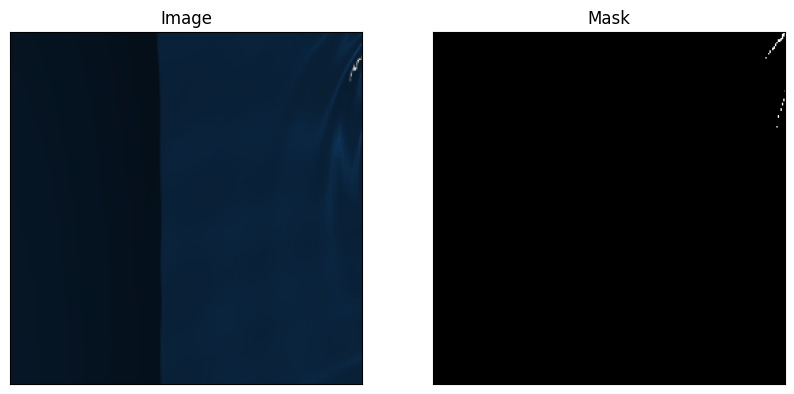

In [137]:
raw_num = random.randint(0, filtered_raw.shape[0]-1)
example_raw = dataset[raw_num]["image"]
example_masked = dataset[raw_num]["label"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot the first image on the left
axes[0].imshow(np.array(example_raw))  # Assuming the first image is grayscale
axes[0].set_title("Image")

# Plot the second image on the right
axes[1].imshow(example_masked, cmap='gray')  # Assuming the second image is grayscale
axes[1].set_title("Mask")

# Hide axis ticks and labels
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

# Display the images side by side
plt.show()

**Dataset Processor for MobileSAM**

In [138]:
import torch
from mobile_sam.utils import transforms

# Image transforms
transform = transforms.ResizeLongestSide(mobile_sam.image_encoder.img_size)

transformed_images = []
for raw in filtered_raw:
    transformed_image = torch.as_tensor(transform.apply_image(raw), device="cpu")
    transformed_image = transformed_image.permute(2, 0, 1)
    transformed_images.append(transformed_image)

# Box transforms
transformed_boxes = []
for box in filtered_boxes:
    transformed_box = torch.as_tensor(transform.apply_boxes(box, (256, 256)), dtype=torch.float, device="cuda")[None, :]
    transformed_boxes.append(transformed_box)

# GT Mask transforms
transformed_masks = []
for mask in filtered_masked:
    transformed_mask = torch.from_numpy(mask).float()
    transformed_masks.append(transformed_mask)

In [139]:
# Splitting data set(train:val:test = 8:1:1)

from sklearn.model_selection import train_test_split

train_images, temp_images, train_boxes, temp_boxes, train_masks, temp_masks = train_test_split(transformed_images, transformed_boxes, transformed_masks, test_size=0.2, random_state=42)
val_images, test_images, val_boxes, test_boxes, val_masks, test_masks = train_test_split(temp_images, temp_boxes, temp_masks, test_size=0.5, random_state=42)

In [140]:
batch_size = 8
train_batch = []
val_batch = []
current_batch = []

#train_batch fill
for img, boxes, mask in zip(train_images, train_boxes, train_masks):
    sample = {
        "image": img,  # The image tensor
        "original_size": (256, 256),  # Original size of the image
        "boxes": boxes.requires_grad_().to("cuda"),  # Boxes for this image
        "ground_truth_mask": mask.to("cuda").requires_grad_()
    }
    current_batch.append(sample)

    if len(current_batch) == batch_size:
        train_batch.append(current_batch)
        current_batch = []

if current_batch:
    train_batch.append(current_batch)

#val_batch fill
for img, boxes, mask in zip(val_images, val_boxes, val_masks):
    sample = {
        "image": img,  # The image tensor
        "original_size": (256, 256),  # Original size of the image
        "boxes": boxes.requires_grad_().to("cuda"),  # Boxes for this image
        "ground_truth_mask": mask.to("cuda").requires_grad_()
    }
    current_batch.append(sample)

    if len(current_batch) == batch_size:
        val_batch.append(current_batch)
        current_batch = []

if current_batch:
    val_batch.append(current_batch)

In [141]:
# Save dataset
torch.save(train_batch, './captures/train_batch.pt')
torch.save(val_batch, './captures/val_batch.pt')


**Reset Model for Training**

In [142]:
train_batch = torch.load('./captures/train_batch.pt')
val_batch = torch.load('./captures/val_batch.pt')
#train_images = torch.load('./captures/filtered_raw.pt')
#train_masks = torch.load('./captures/filtered_masked.pt')
#train_boxes = torch.load('./captures/filtered_boxes.pt')

C:\Users\user\AppData\Local\Temp\ipykernel_25860\519653501.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_batch = torch.load('./captures/train_batch.pt')
C:\Users

In [143]:
from mobile_sam import sam_model_registry, SamPredictor

model_type = "vit_t"
sam_checkpoint = "model/MobileSAM_Vortex_checkpoint.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"

mobile_sam = sam_model_registry["vit_t"](checkpoint="weights/mobile_sam.pt")
mobile_sam.to(device=device)
predictor = SamPredictor(mobile_sam)

c:\Users\user\Documents\Viscnet\MobileSAM_Vortex\mobile_sam\build_sam.py:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


In [144]:
# Freeze layers in MobileSAM
for name, param in mobile_sam.named_parameters():
    if name.startswith("image_encoder"):  # Assuming "image_encoder" corresponds to the vision encoder
        param.requires_grad = False  # Freeze the vision encoder
    elif name.startswith("prompt_encoder"):  # Assuming "prompt_encoder" exists in MobileSAM
        param.requires_grad = False  # Freeze the prompt encoder

# Verify trainable parameters
trainable_params = sum(p.numel() for p in mobile_sam.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

# Iterate through all parameters and check their trainable status
print("MobileSAM Parameters:")
for name, param in mobile_sam.named_parameters():
        print(f"{name}: {'Trainable' if param.requires_grad else 'Frozen'}")

# Count the total trainable parameters
trainable_params = sum(p.numel() for p in mobile_sam.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters in MobileSAM: {trainable_params}")

Trainable parameters: 4058340
MobileSAM Parameters:
image_encoder.patch_embed.seq.0.c.weight: Frozen
image_encoder.patch_embed.seq.0.bn.weight: Frozen
image_encoder.patch_embed.seq.0.bn.bias: Frozen
image_encoder.patch_embed.seq.2.c.weight: Frozen
image_encoder.patch_embed.seq.2.bn.weight: Frozen
image_encoder.patch_embed.seq.2.bn.bias: Frozen
image_encoder.layers.0.blocks.0.conv1.c.weight: Frozen
image_encoder.layers.0.blocks.0.conv1.bn.weight: Frozen
image_encoder.layers.0.blocks.0.conv1.bn.bias: Frozen
image_encoder.layers.0.blocks.0.conv2.c.weight: Frozen
image_encoder.layers.0.blocks.0.conv2.bn.weight: Frozen
image_encoder.layers.0.blocks.0.conv2.bn.bias: Frozen
image_encoder.layers.0.blocks.0.conv3.c.weight: Frozen
image_encoder.layers.0.blocks.0.conv3.bn.weight: Frozen
image_encoder.layers.0.blocks.0.conv3.bn.bias: Frozen
image_encoder.layers.0.blocks.1.conv1.c.weight: Frozen
image_encoder.layers.0.blocks.1.conv1.bn.weight: Frozen
image_encoder.layers.0.blocks.1.conv1.bn.bias: F

**Training Loop**

In [ ]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import monai

# Initialize the optimizer for the mask decoder
optimizer = Adam(mobile_sam.mask_decoder.parameters(), lr=1e-3, weight_decay=0)

# Define the segmentation loss function
# You can choose between DiceFocalLoss, FocalLoss, or DiceCELoss
seg_loss = monai.losses.DiceCELoss(sigmoid=True, squared_pred=True, reduction='mean')

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [169]:
from tqdm import tqdm
from statistics import mean
import torch
import math

# Training loop
num_epochs = 50
device = "cuda" if torch.cuda.is_available() else "cpu"
mobile_sam.to(device)

mobile_sam.train()
for epoch in range(num_epochs):
    train_losses = []
    for batch_group in tqdm(train_batch, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        #stacking mask/training model/mask retrieve
        mask_batch = torch.stack([sample["ground_truth_mask"].unsqueeze(0).to(device) for sample in batch_group]) # 8 masked images rgb
        outputs = mobile_sam(batched_input = batch_group, multimask_output = False) #requires the whole batch
        predicted_masks = torch.stack([output["masks"].squeeze(1).float() for output in outputs])

        #loss calculation/optimization
        train_loss = seg_loss(predicted_masks, mask_batch)
        train_losses.append(train_loss.item())
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        if (len(train_losses)) % 100 == 0:
            print(f'Batch {len(train_losses)+1}/{len(train_batch)} - Training Loss: {train_loss.item():.2f}')

    mean_train_loss = mean(train_losses)

    # Validation loss calculation
    mobile_sam.eval()
    val_losses = []
    with torch.no_grad():
        for batch_group in tqdm(val_batch, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
            mask_batch = torch.stack([sample["ground_truth_mask"].unsqueeze(0).to(device) for sample in batch_group])
            outputs = mobile_sam(batched_input=batch_group, multimask_output=False)
            predicted_masks = torch.stack([output["masks"].squeeze(1).float() for output in outputs])
            val_loss = seg_loss(predicted_masks, mask_batch)
            val_losses.append(val_loss.item())
    mean_val_loss = mean(val_losses)
     
    print(f'EPOCH: {epoch + 1}/{num_epochs} - Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f}')
    scheduler.step(val_loss)
    mobile_sam.train()


Epoch 1/50 - Training:  15%|█▌        | 100/651 [00:41<03:46,  2.44it/s]

Batch 101/651 - Training Loss: 0.86


Epoch 1/50 - Training:  31%|███       | 200/651 [01:21<03:04,  2.45it/s]

Batch 201/651 - Training Loss: 0.89


Epoch 1/50 - Training:  46%|████▌     | 300/651 [02:02<02:23,  2.45it/s]

...

Batch 501/651 - Training Loss: 0.75


Epoch 50/50 - Training:  92%|█████████▏| 600/651 [04:06<00:20,  2.45it/s]

Batch 601/651 - Training Loss: 0.63


Epoch 50/50 - Validation: 100%|██████████| 82/82 [00:26<00:00,  3.12it/s]

EPOCH: 50/50 - Train Loss: 0.6599 | Val Loss: 0.8117


In [170]:
# Save the state_dict after moving layers
torch.save(mobile_sam.state_dict(), "model/MobileSAM_Vortex_checkpoint.pth")

**Inference**

In [171]:
from mobile_sam import sam_model_registry, SamPredictor

vortex_model = sam_model_registry["vit_t"](checkpoint="model/MobileSAM_Vortex_checkpoint.pth")
vortex_model.eval()
predictor = SamPredictor(vortex_model)

c:\Users\user\Documents\Viscnet\MobileSAM_Vortex\mobile_sam\build_sam.py:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


[[[232 244 251]
  [232 244 251]
  [231 244 250]
  ...
  [  0 255   0]
  [  1 255   0]
  [  1 255   0]]

 [[232 244 251]
  [232 244 251]
  [231 244 250]
  ...
  [  0 255   0]
  [  1 255   0]
  [  1 255   0]]

 [[233 245 251]
  [233 245 251]
  [232 244 251]
  ...
  [  0 255   0]
  [  0 255   0]
  [  0 255   0]]

 ...

 [[219 235 246]
  [219 235 246]
  [218 234 246]
  ...
  [218 235 247]
  [217 235 247]
  [217 235 247]]

 [[220 235 246]
  [220 235 246]
  [218 234 246]
  ...
  [220 236 247]
  [219 235 247]
  [219 235 247]]

 [[220 235 246]
  [220 235 246]
  [218 234 246]
  ...
  [220 236 247]
  [219 235 247]
  [219 235 247]]]


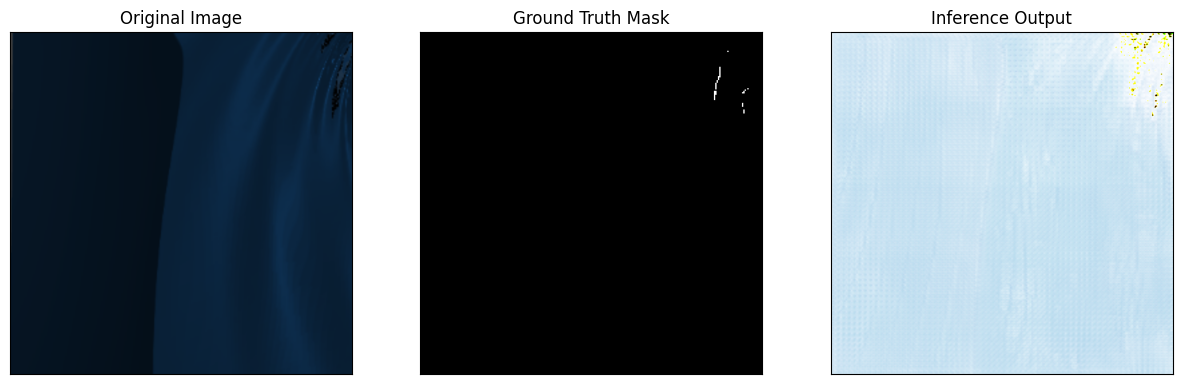

[[[218 240 248]
  [218 240 248]
  [217 240 247]
  ...
  [197 230 243]
  [198 231 243]
  [198 231 243]]

 [[218 240 248]
  [218 240 248]
  [217 240 247]
  ...
  [197 230 243]
  [198 231 243]
  [198 231 243]]

 [[217 240 248]
  [217 240 248]
  [217 239 247]
  ...
  [197 230 242]
  [199 231 243]
  [199 231 243]]

 ...

 [[249 252 255]
  [249 252 255]
  [247 251 254]
  ...
  [181 222 237]
  [179 221 236]
  [179 221 236]]

 [[248 252 255]
  [248 252 255]
  [247 251 254]
  ...
  [181 222 237]
  [178 221 236]
  [178 221 236]]

 [[248 252 255]
  [248 252 255]
  [247 251 254]
  ...
  [181 222 237]
  [178 221 236]
  [178 221 236]]]


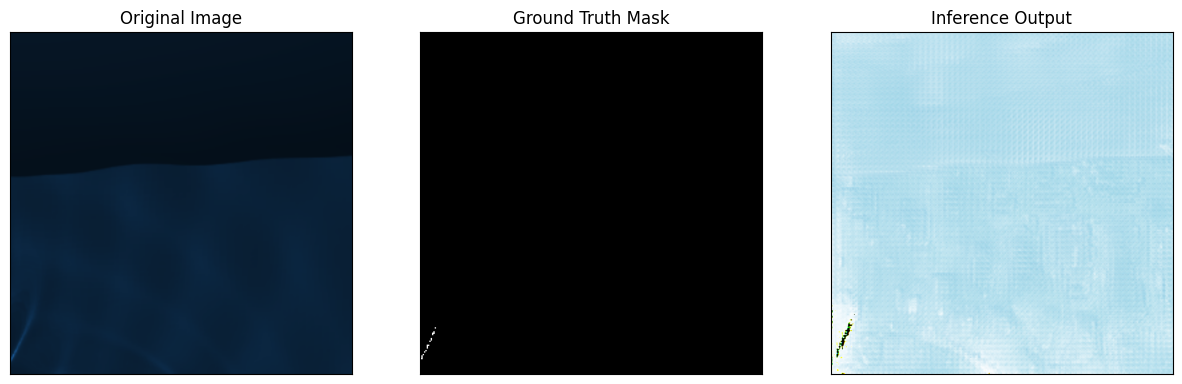

[[[243 246 253]
  [243 246 253]
  [241 246 252]
  ...
  [234 247 252]
  [234 248 253]
  [234 248 253]]

 [[243 246 253]
  [243 246 253]
  [241 246 252]
  ...
  [234 247 252]
  [234 248 253]
  [234 248 253]]

 [[243 246 253]
  [243 246 253]
  [241 246 252]
  ...
  [235 248 253]
  [236 248 253]
  [236 248 253]]

 ...

 [[238 243 250]
  [238 243 250]
  [235 243 250]
  ...
  [220 233 246]
  [217 232 245]
  [217 232 245]]

 [[238 244 250]
  [238 244 250]
  [236 243 250]
  ...
  [223 234 246]
  [220 232 246]
  [220 232 246]]

 [[238 244 250]
  [238 244 250]
  [236 243 250]
  ...
  [223 234 246]
  [220 232 246]
  [220 232 246]]]


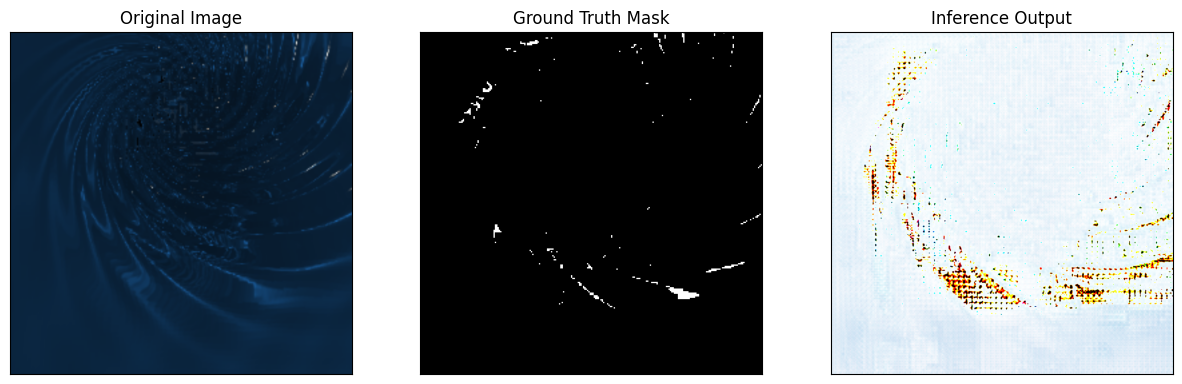

In [178]:
import random
test_number = 3

for i in range(test_number):
    idx = random.randint(0,len(test_images)-1)
    
    test_image = test_images[idx].cpu().numpy()
    test_image = np.transpose(test_image, (1,2,0))
    test_box = test_boxes[idx].cpu().numpy()
    test_mask = test_masks[idx].cpu().numpy()

    predictor.set_image(test_image)
    masks, _, _ = predictor.predict(box = test_box, return_logits=True)
    
    masks = np.transpose(masks,(1,2,0))
    masks = masks.astype(np.uint8)
    fig, axes = plt.subplots(1,3,figsize=(15,5))
    print(masks)

    axes[0].imshow(test_image)
    axes[0].set_title("Original Image")

    axes[1].imshow(test_mask, cmap='gray')
    axes[1].set_title("Ground Truth Mask")

    axes[2].imshow(masks)
    axes[2].set_title("Inference Output")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])

    plt.show()


In [ ]:
torch.cuda.empty_cache()